In [ ]:
#Library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression


In [ ]:
#Creating the Dry Beans dataset
dryBeans = pd.read_excel('/content/Dry_Bean_Dataset.xlsx')
dryBeans

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


##James-Question 1

1. Data Partitioning and Timing

In [ ]:
#Label encoder for encding our y variable
le = LabelEncoder()
#Assigning input and output variables
X = dryBeans.drop('Class', axis=1)
y = le.fit_transform(dryBeans['Class'])
#Assigning 10% of set to testing
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=.1, stratify=y, random_state=2026)
#Assigning 20% to validation
X_train,X_val,y_train,y_val = train_test_split(X_train, y_train, test_size=.2/(1-.1), stratify=y_train, random_state=2026)

In [ ]:
#Printing the X partitions
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(9527, 16)
(2722, 16)
(1362, 16)


In [ ]:
#Printing the Y partitions
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(9527,)
(2722,)
(1362,)


**Explain why stratification is essential for maintaining consistent class distributions across partitions.**

Stratification ensures that each data partition maintains approximately the same class distribution as the original dataset. This prevents the overrepresentation or underrepresentation of certain classes within the sets. The model is better trained on data that more accurately reflects the overall population.The model's ability to generalize to unseen data and produce more reliable evaluation metrics is improved.

2. KNN Implementation

In [ ]:
#Scale the input values
scaler = StandardScaler()
#Assigning input variables
X = dryBeans[['ConvexArea','Extent']]
#Assigning 10% of set to testing
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=.1, stratify=y, random_state=2026)
#Assigning 20% to validation
X_train,X_val,y_train,y_val = train_test_split(X_train, y_train, test_size=.2/(1-.1), stratify=y_train, random_state=2026)
#Making array for plot
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
#Fit the model
%%time
knnModelScaled = KNeighborsClassifier()
knnModelScaled.fit(X_train_scaled, y_train)

CPU times: user 7.2 ms, sys: 0 ns, total: 7.2 ms
Wall time: 7.62 ms


KNeighborsClassifier()

In [ ]:
#Making array for plot
X_array = X_train.values

In [ ]:
#Fit the model
%%time
KnnModelUnscaled = KNeighborsClassifier()
KnnModelUnscaled.fit(X_array, y_train)

CPU times: user 4.69 ms, sys: 0 ns, total: 4.69 ms
Wall time: 4.73 ms


KNeighborsClassifier()

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


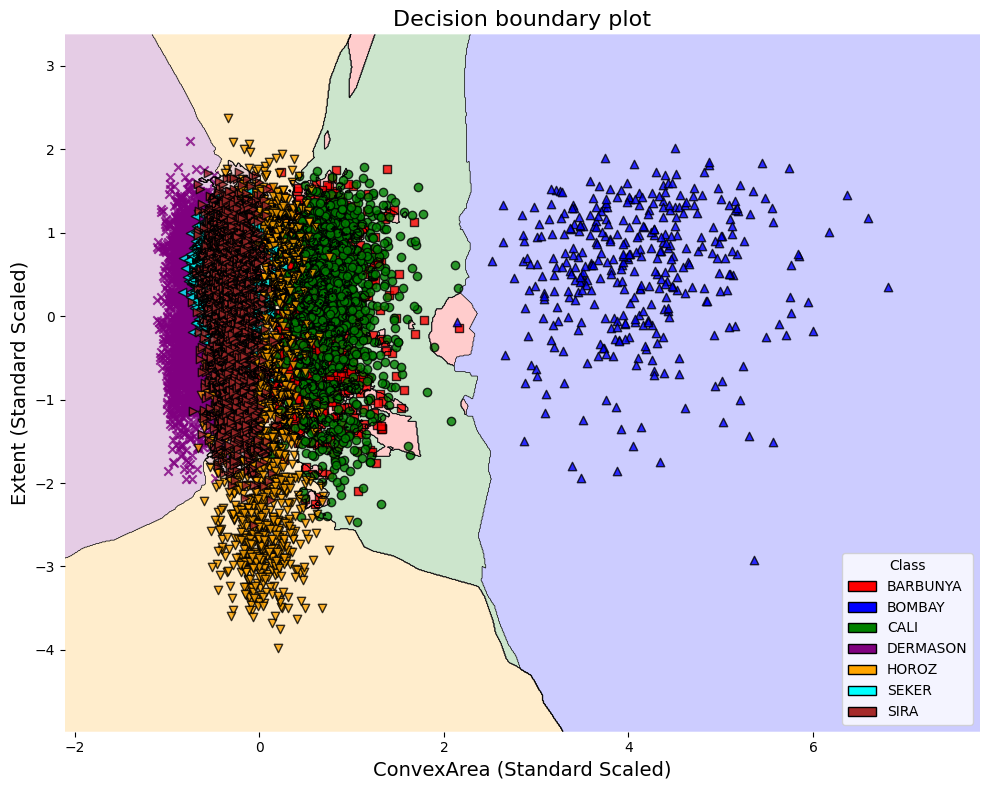

In [ ]:
# Define colors to ensure legend matches plot
custom_colors = 'red,blue,green,purple,orange,cyan,brown'
color_list = custom_colors.split(',')

# Set background opacity to 20%
contourf_kwargs = {"alpha": 0.2}

# Create a figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot decision boundaries
plot_decision_regions(
    X_train_scaled, y_train, clf=knnModelScaled, legend=0, ax=ax,
    contourf_kwargs=contourf_kwargs, colors=custom_colors
)

# Set labels manually
ax.set_title("Decision boundary plot", fontsize=16)
ax.set_xlabel("ConvexArea (Standard Scaled)", fontsize=14)
ax.set_ylabel("Extent (Standard Scaled)", fontsize=14)

# le.classes_ gives the class names corresponding to integers
class_names = le.classes_
#Creating our legend
legend_elements = [Patch(facecolor=color_list[i], edgecolor='black', label=class_names[i])
                   for i in sorted(np.unique(y_train))]
ax.legend(handles=legend_elements, title="Class", loc='lower right')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


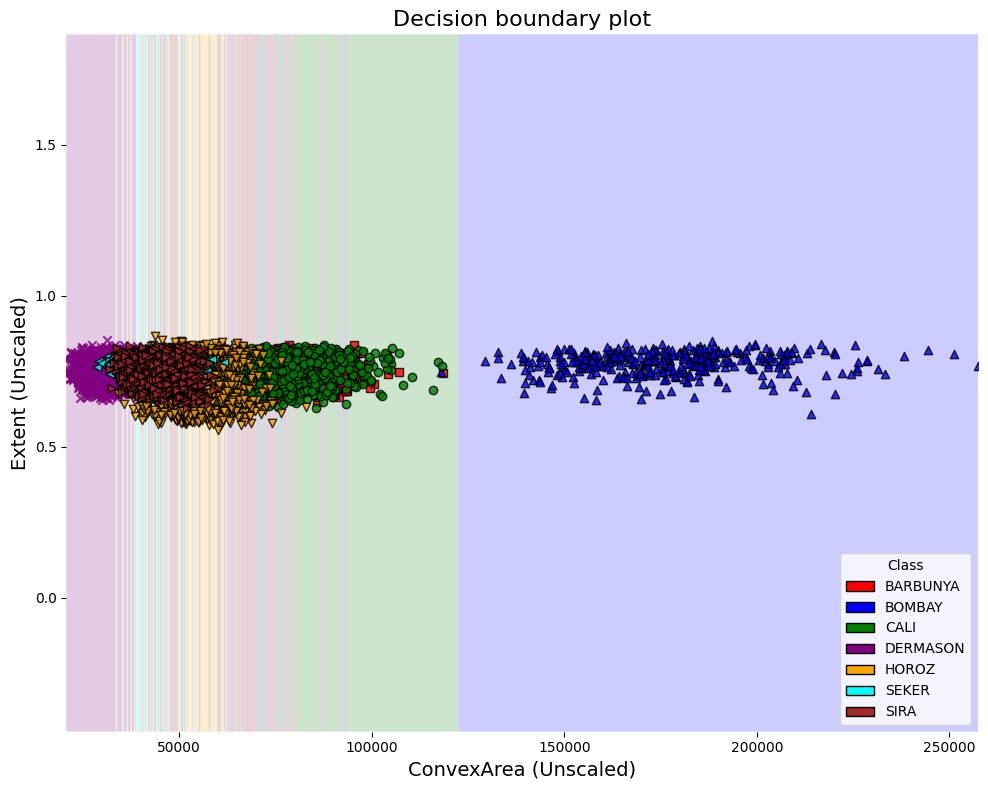

In [ ]:
# Define colors to ensure legend matches plot
custom_colors = 'red,blue,green,purple,orange,cyan,brown'
color_list = custom_colors.split(',')

# Set background opacity to 20%
contourf_kwargs = {"alpha": 0.2}

# Create a figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot decision boundaries
plot_decision_regions(
    X_array, y_train.ravel(), clf=KnnModelUnscaled, legend=0, ax=ax,
    contourf_kwargs=contourf_kwargs, contour_kwargs={"linewidths": 0}, colors=custom_colors
)

# Set labels manually
ax.set_title("Decision boundary plot", fontsize=16)
ax.set_xlabel("ConvexArea (Unscaled)", fontsize=14)
ax.set_ylabel("Extent (Unscaled)", fontsize=14)

# le.classes_ gives the class names corresponding to integers
class_names = le.classes_
#Creating our legend
legend_elements = [Patch(facecolor=color_list[i], edgecolor='black', label=class_names[i])
                   for i in sorted(np.unique(y_train))]
ax.legend(handles=legend_elements, title="Class", loc='lower right')

plt.tight_layout()
plt.show()

**Analyze why failing to standardize features with different numeric ranges negatively impacts distance-based calculations like Euclidean or Minkowski distance**

In distance-based calculations, outliers and features with larger magnitudes heavily influence the computations. These features will have dominate mathematical calculations without taking into account the actual effect it has on prediction. This all causes the model to be less accurate and unable to effectively generalize. The resulting decision boundaries are not as reliable as those from a model with scaled data.

3. Parameter Tuning

In [ ]:
#Fit the model
%%time
knnModel3 = KNeighborsClassifier(n_neighbors=3)
knnModel3.fit(X_train_scaled, y_train)

CPU times: user 8.01 ms, sys: 1 µs, total: 8.01 ms
Wall time: 13.9 ms


KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Fit the model
%%time
knnModel5 = KNeighborsClassifier(n_neighbors=5)
knnModel5.fit(X_train_scaled, y_train)

CPU times: user 7.82 ms, sys: 0 ns, total: 7.82 ms
Wall time: 8.55 ms


KNeighborsClassifier()

In [ ]:
#Fit the model
%%time
knnModel7 = KNeighborsClassifier(n_neighbors=7)
knnModel7.fit(X_train_scaled, y_train)

CPU times: user 7.79 ms, sys: 0 ns, total: 7.79 ms
Wall time: 7.98 ms


KNeighborsClassifier(n_neighbors=7)

In [ ]:
#Fit the model
%%time
knnModel9 = KNeighborsClassifier(n_neighbors=9)
knnModel9.fit(X_train_scaled, y_train)

CPU times: user 6.21 ms, sys: 0 ns, total: 6.21 ms
Wall time: 6.27 ms


KNeighborsClassifier(n_neighbors=9)

In [ ]:
#Finding the best score
scores = {}
for k in [3,5,7,9]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    scores[k] = model.score(X_val_scaled, y_val)
print(scores)
best_k = max(scores, key=scores.get)
print("best_k:", best_k)

{3: 0.6399706098457016, 5: 0.6542983100661278, 7: 0.665686994856723, 9: 0.6726671565025716}
best_k: 9


KNN Model 9 has the best score.

/usr/local/lib/python3.12/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


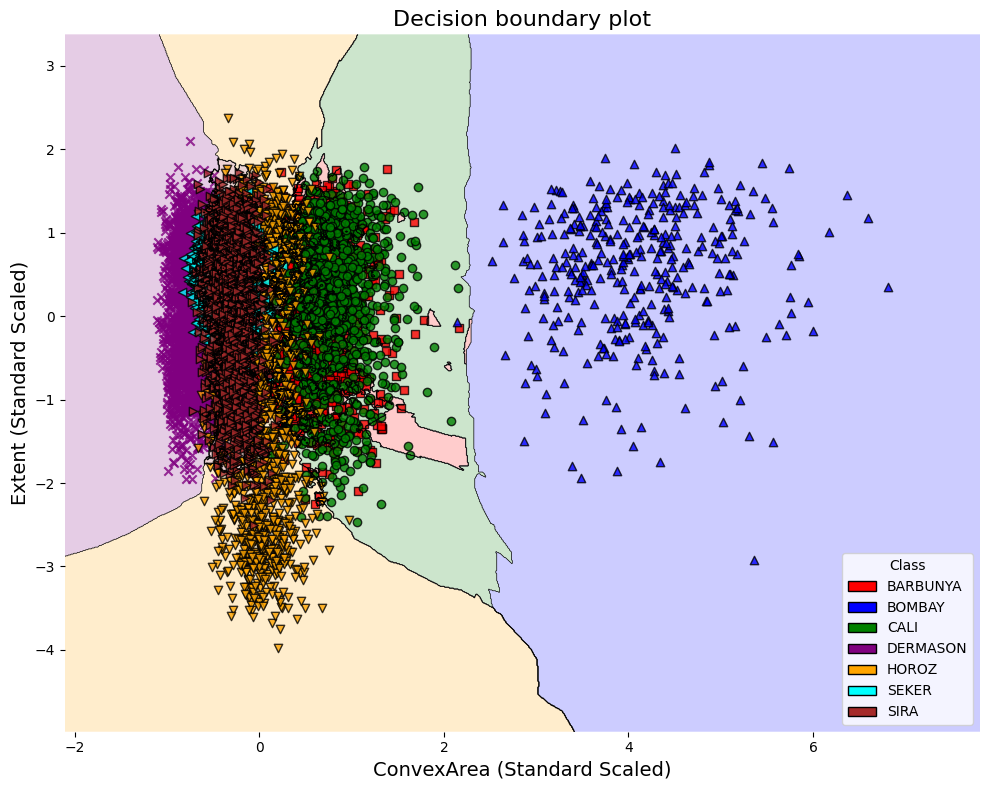

In [ ]:
# Define colors to ensure legend matches plot
custom_colors = 'red,blue,green,purple,orange,cyan,brown'
color_list = custom_colors.split(',')

# Set background opacity to 20%
contourf_kwargs = {"alpha": 0.2}

# Create a figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot decision boundaries
plot_decision_regions(
    X_train_scaled, y_train, clf=knnModel9, legend=0, ax=ax,
    contourf_kwargs=contourf_kwargs, colors=custom_colors
)

# Set labels manually
ax.set_title("Decision boundary plot", fontsize=16)
ax.set_xlabel("ConvexArea (Standard Scaled)", fontsize=14)
ax.set_ylabel("Extent (Standard Scaled)", fontsize=14)

# le.classes_ gives the class names corresponding to integers
class_names = le.classes_
#Creating our legend
legend_elements = [Patch(facecolor=color_list[i], edgecolor='black', label=class_names[i])
                   for i in sorted(np.unique(y_train))]
ax.legend(handles=legend_elements, title="Class", loc='lower right')

plt.tight_layout()
plt.show()

# **# Kaviya** - **Question 2**

# **1.Generative Models: GNB and LDA**

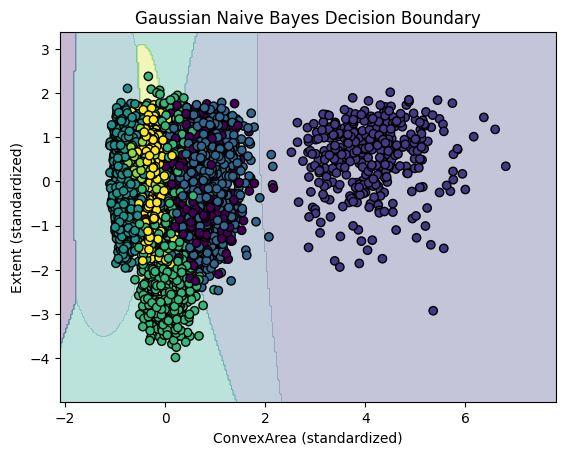

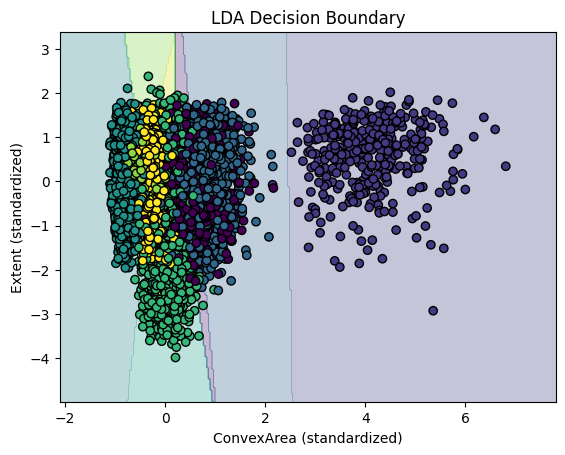

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel("ConvexArea (standardized)")
    plt.ylabel("Extent (standardized)")
    plt.title(title)
    plt.show()

# Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
plot_decision_boundary(gnb, X_train_scaled, y_train, "Gaussian Naive Bayes Decision Boundary")

# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)
plot_decision_boundary(lda, X_train_scaled, y_train, "LDA Decision Boundary")


The decision boundaries of Gaussian Naive Bayes (GNB) and Linear Discriminant Analysis (LDA) look quite different because of the assumptions each method makes:

Gaussian Naive Bayes (GNB): GNB assumes that all features are independent from each other, once you know the class. It models each feature with a Gaussian (bell curve), but because it ignores correlations between features, each class ends up forming its own “elliptical region” in the feature space. These regions can vary in shape and size for each class, which often leads to curved (non-linear) decision boundaries.

Linear Discriminant Analysis (LDA): LDA assumes that all classes share the same covariance structure—in other words, the spread and relationship between features is the same for every class. This assumption simplifies the math and produces straight-line decision boundaries. The shared covariance cancels out the curves that would otherwise appear, giving linear separation between classes.

In the plots:

The GNB plot shows wiggly, curved lines separating the classes.

The LDA plot shows straight lines dividing the feature space.

# **2. Complexity & Non-Linearity: QDA**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


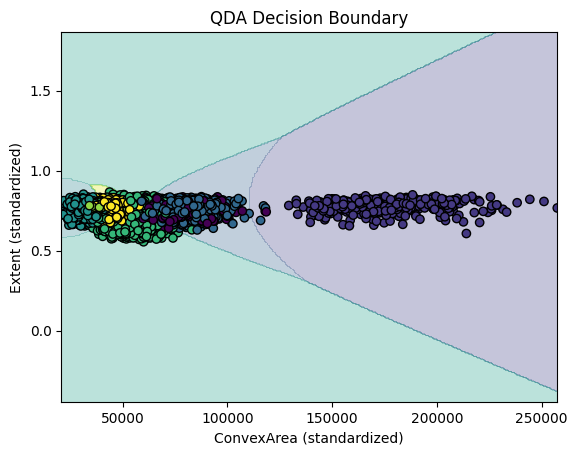

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolor='k')
    plt.xlabel("ConvexArea (standardized)")
    plt.ylabel("Extent (standardized)")
    plt.title(title)
    plt.show()
qda.fit(X_train, y_train)
plot_decision_boundary(qda, X_train, y_train, "QDA Decision Boundary")


Quadratic Discriminant Analysis (QDA) usually works better than Linear Discriminant Analysis (LDA) when the classes have different shapes, sizes, or orientations in the feature space. Here’s why:

LDA assumes all classes share the same spread and relationships between features. This forces it to draw straight-line boundaries, which can’t adapt to classes with different shapes.

QDA lets each class have its own spread and orientation, which allows it to draw curved (quadratic) boundaries that fit the classes more naturally.

Example Scenario:

Imagine two classes:

Class A is tightly clustered and roughly round.

Class B is stretched out diagonally like an ellipse.

LDA will try to separate them with a straight line. This line might cut through the elongated class, misclassifying many points.

QDA can fit an ellipse around each class, allowing the boundary to curve around the round class and follow the stretched shape of the elongated class.

In this case, QDA captures the true shapes of the classes, so it usually performs better than LDA.

# **3. Discriminative Modeling: Logistic Regression**

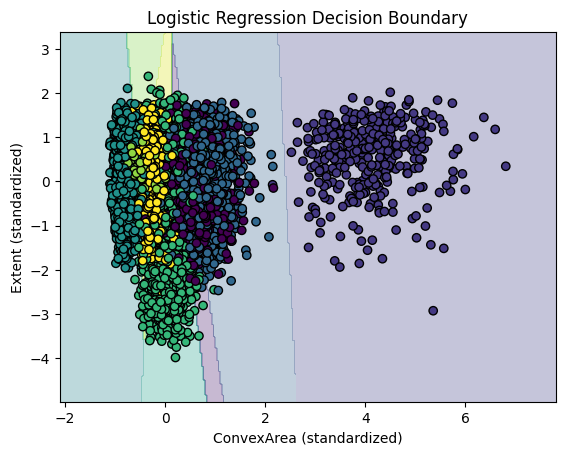

In [ ]:


def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel("ConvexArea (standardized)")
    plt.ylabel("Extent (standardized)")
    plt.title(title)
    plt.show()

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Initialize logistic regression with more iterations
logreg = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500)

# Fit model (y_train is already ndarray)
logreg.fit(X_train_scaled, y_train.ravel())

# Convert to numpy arrays for plotting
X_train_np = X_train_scaled
y_train_np = y_train.ravel()

# Plot decision boundary
plot_decision_boundary(logreg, X_train_np, y_train_np, "Logistic Regression Decision Boundary")

In [ ]:
coef = logreg.coef_[0]
intercept = logreg.intercept_[0]

print("ConvexArea weight:", coef[0])
print("Extent weight:", coef[1])
print("Intercept:", intercept)


ConvexArea weight: 7.083821623623403
Extent weight: -0.04792611865639623
Intercept: 2.0666781380736814


In a Logistic Regression model, the coefficients (weights) tell us how each feature affects the probability of a data point belonging to a certain class. Here’s what the numbers mean for this model:

ConvexArea (7.08): This is a large positive weight. It means that as ConvexArea increases, the probability of the observation belonging to the target class increases a lot. So, ConvexArea is a strong predictor in this model.

Extent (-0.048): This is a very small negative weight. It slightly decreases the probability of the observation being in the target class, but its effect is almost negligible. Extent doesn’t contribute much to differentiating the classes.

Intercept (2.07): The intercept is the baseline log-odds of the class when all features are zero. It basically shifts the decision boundary.

In short: ConvexArea is by far the most important feature in this model, while Extent has very little influence.

# **Yashwanth - Question 3**

# **3 Open-Ended Analysis — Interpretability vs. Performance**

# 3.1 Model Comparison: Logistic Regression vs. k-Nearest Neighbors (Interpretability)

* Logistic Regression is a parametric model that learns explicit coefficients (weights) for each input feature.

* These coefficients clearly show the contribution and influence of features such as ConvexArea and Extent on the classification outcome.

* The sign and magnitude of the coefficients indicate whether a feature increases or decreases the likelihood of a class.

* This makes Logistic Regression highly interpretable and transparent.

* In contrast, k-Nearest Neighbors does not learn model parameters or feature weights.

* kNN classifies data points based on the majority class of nearby neighbors using distance measures.

* Since it provides no direct explanation of feature importance, kNN is less interpretable.

# 3.2 Case Study: Model Recommendation for Explaining Classification Results

* Logistic Regression is the most suitable model for explaining predictions to non-technical stakeholders.

* It handles input variables by assigning clear numerical weights, making decisions easy to interpret.

* The model allows simple explanations, such as identifying which feature contributed more to the classification.

* Gaussian Naive Bayes provides probabilistic outputs, but relies on independence assumptions that may be difficult to explain.

* k-Nearest Neighbors depends only on similarity between data points and lacks explicit reasoning.

* Therefore, Logistic Regression offers the best balance of interpretability and clarity among the models.